In [5]:
# %%
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [12]:
# %%
# Initialize dictionary to collect results from existing models
all_results = defaultdict(list)
base_path = "/n/data2/hms/dbmi/kyu/lab/chb3333/gem-patho/models/actual_final_results"

# Loop over model types, batches, and experiments for the original models.
for gen_image in ['genetics_and_image', 'only_genetics', 'only_image']:
    for batch in ['ct_batch', 'all_batch']:
        for exp in ['cancertypebatching_exp_0_warmup_0', 
                    'cancertypebatching_exp_1_warmup_10', 
                    'cancertypebatching_exp_0_phase2_10', 
                    'cancertypebatching_exp_1_phase2_0']:
            path = f"{base_path}/{gen_image}/{batch}/{exp}/global_test_cindices.csv"
            try:
                data = pd.read_csv(path)
                for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                    all_results['gen_image'].append(gen_image)
                    all_results['batch'].append(batch)
                    all_results['exp'].append(exp)
                    all_results['cancer'].append(cancer)
                    all_results['c_index'].append(c_idx)
            except Exception as e:
                # Skip missing files
                pass


In [13]:
# %%
# Append improved fusion model results; these will be added after the original models.
improved_models = {
    "layer_norm_fusion_mlp": ["cancertypebatching_exp_0_phase2_10", "cancertypebatching_exp_1_phase2_0"],
    "layer_norm_fusion_mlp_lowerlr": ["cancertypebatching_exp_0_phase2_10", "cancertypebatching_exp_1_phase2_0"]
}
base_improved_path = "/home/chb3333/yulab/chb3333/gem-patho/models/improved_fusing"

for model_type, exp_list in improved_models.items():
    for exp in exp_list:
        path = f"{base_improved_path}/{model_type}/{exp}/global_test_cindices.csv"
        try:
            data = pd.read_csv(path)
            for cancer, c_idx in zip(data['cancer_type'], data['c_index']):
                # For improved models, record the model type and label the batch as "improved"
                all_results['gen_image'].append(model_type)
                all_results['batch'].append("improved")
                all_results['exp'].append(exp)
                all_results['cancer'].append(cancer)
                all_results['c_index'].append(c_idx)
        except Exception as e:
            pass


In [14]:
# %%
# Create a DataFrame from the collected results.
df = pd.DataFrame(all_results)

# Group by model identifiers and calculate the average c-index and standard error.
grouped = df.groupby(['gen_image', 'batch', 'exp'])['c_index'].agg(['mean', 'sem']).reset_index()
grouped.rename(columns={'mean': 'avg_c_index', 'sem': 'se_c_index'}, inplace=True)

# Create a column that uniquely identifies each model.
grouped["model"] = grouped["gen_image"] + "_" + grouped["batch"] + "_" + grouped["exp"]

# Compute the 95% confidence interval (CI = 1.96 * standard error).
grouped["ci95"] = 1.96 * grouped["se_c_index"]


In [15]:
# %%
# Define a dictionary mapping model numbers (1 to 16) to the full model names.
model_names = {
    1: 'genetics_and_image_ct_batch_cancertypebatching_exp_0_warmup_0',
    2: 'genetics_and_image_ct_batch_cancertypebatching_exp_1_warmup_10',
    3: 'genetics_and_image_all_batch_cancertypebatching_exp_0_phase2_10',
    4: 'genetics_and_image_all_batch_cancertypebatching_exp_1_phase2_0',
    5: 'only_genetics_ct_batch_cancertypebatching_exp_0_warmup_0',
    6: 'only_genetics_ct_batch_cancertypebatching_exp_1_warmup_10',
    7: 'only_genetics_all_batch_cancertypebatching_exp_0_phase2_10',
    8: 'only_genetics_all_batch_cancertypebatching_exp_1_phase2_0',
    9: 'only_image_ct_batch_cancertypebatching_exp_0_warmup_0',
    10: 'only_image_ct_batch_cancertypebatching_exp_1_warmup_10',
    11: 'only_image_all_batch_cancertypebatching_exp_0_phase2_10',
    12: 'only_image_all_batch_cancertypebatching_exp_1_phase2_0',
    13: 'layer_norm_fusion_mlp_improved_cancertypebatching_exp_0_phase2_10',
    14: 'layer_norm_fusion_mlp_improved_cancertypebatching_exp_1_phase2_0',
    15: 'layer_norm_fusion_mlp_lowerlr_improved_cancertypebatching_exp_0_phase2_10',
    16: 'layer_norm_fusion_mlp_lowerlr_improved_cancertypebatching_exp_1_phase2_0'
}

# Create an inverse mapping from the full model string to its number.
name_models = {v: k for k, v in model_names.items()}

# Map each model's full name to its assigned number.
grouped["model_number"] = grouped["model"].map(name_models)

# Sort the DataFrame by model number (ascending 1–16) so that the x-axis order is correct.
grouped.sort_values("model_number", inplace=True)
grouped.reset_index(drop=True, inplace=True)


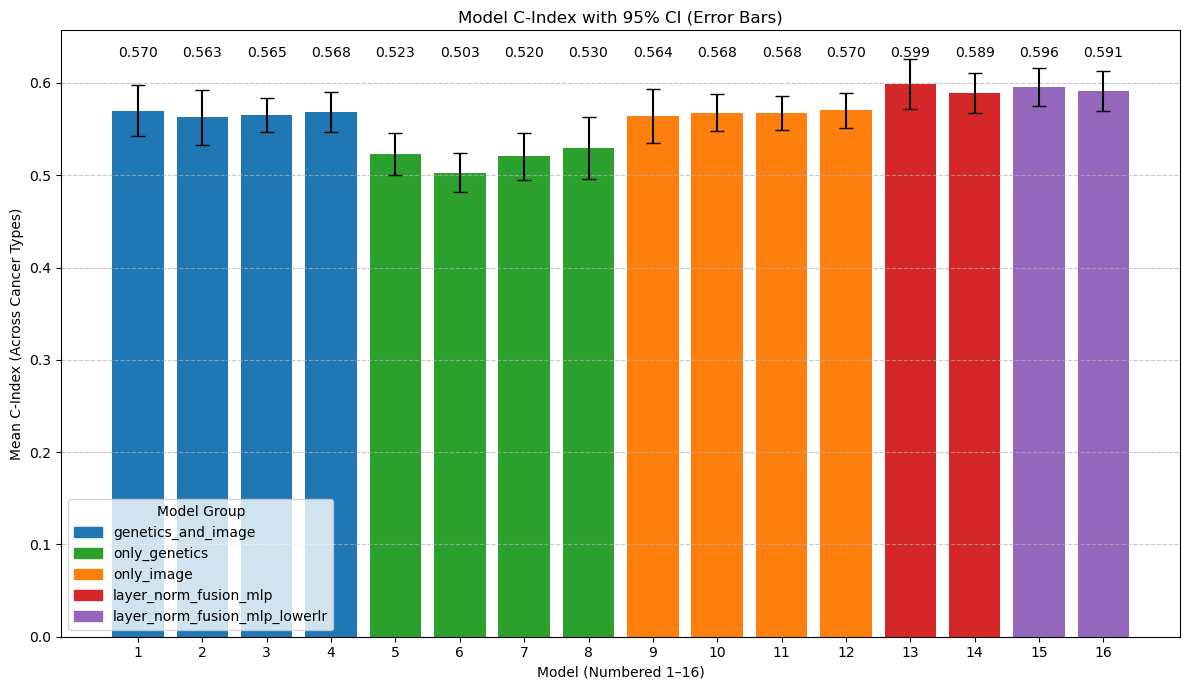

In [23]:
# %%
# Define colors for each group. (These colors are arbitrary and can be adjusted.)
color_map = {
    "genetics_and_image": "tab:blue",
    "only_genetics": "tab:green",
    "only_image": "tab:orange",
    "layer_norm_fusion_mlp": "tab:red",
    "layer_norm_fusion_mlp_lowerlr": "tab:purple"
}

# For the purpose of color assignment, extract the main group from the model string.
def get_color(group_str):
    # If the model name contains the improved tag, return the corresponding color.
    if "layer_norm_fusion_mlp_lowerlr" in group_str:
        return color_map["layer_norm_fusion_mlp_lowerlr"]
    elif "layer_norm_fusion_mlp" in group_str:
        return color_map["layer_norm_fusion_mlp"]
    elif "genetics_and_image" in group_str:
        return color_map["genetics_and_image"]
    elif "only_genetics" in group_str:
        return color_map["only_genetics"]
    elif "only_image" in group_str:
        return color_map["only_image"]
    else:
        return "tab:gray"

# Map each model (from its full identifier) to a color.
colors = grouped["model"].apply(get_color)

# Create the final bar plot.
plt.figure(figsize=(12, 7))
bars = plt.bar(range(len(grouped)), grouped["avg_c_index"],
               yerr=grouped["ci95"], capsize=5, color=colors)
# Use the model number for x-axis tick labels.
plt.xticks(range(len(grouped)), grouped["model_number"], rotation=0)
plt.ylabel("Mean C-Index (Across Cancer Types)")
plt.xlabel("Model (Numbered 1–16)")
plt.title("Model C-Index with 95% CI (Error Bars)")
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add numerical labels above each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, 0.625,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# Build a legend for the different model groups.
legend_patches = []
used_labels = set()
for group_key, col in color_map.items():
    # Only add one patch per color.
    if group_key not in used_labels:
        legend_patches.append(mpatches.Patch(color=col, label=group_key))
        used_labels.add(group_key)
plt.legend(handles=legend_patches, title="Model Group")

plt.show()
